# <p style="color:#07d839; font-family:sans-serif;"> 😀 Sentiment Analysis — Análisis de Sentimiento 🥲 </p>

---

## <p style="color:#07d839;">🎯 Objetivo de la Tarea</p>

El propósito de este análisis es desentrañar la carga emocional oculta tras las letras de diferentes géneros musicales. Buscamos responder preguntas clave sobre la naturaleza sentimental de la música:

*   **Polaridad:** ¿Qué géneros son predominantemente positivos, negativos o neutros?
*   **Intensidad:** ¿Existen géneros con una carga emocional negativa o positiva mucho más marcada?
*   **Emociones específicas:** ¿Qué géneros destacan en sentimientos como la **tristeza**, **ira**, **alegría** o **amor**?
*   **Variabilidad:** ¿Es el sentimiento constante dentro de un género o existe mucha disparidad entre canciones?

---

## <p style="color:#07d839;">⚙️ Metodología del Análisis</p>

La unidad básica de estudio es **cada canción individual**. El flujo de procesamiento sigue esta estructura lógica:

> **Flujo de Trabajo:**
> `Canción` ➔ `Letra (Texto)` ➔ `Modelo de Sentimiento` ➔ `Score (Positivo/Negativo/Neutro)`

### Procesamiento por Género
Una vez obtenido el score individual, agruparemos los resultados para obtener una visión panorámica por categoría:

| Género Musical | Métricas a Calcular |
| :--- | :--- |
| **Pop** | Media de sentimiento, % Positivas, % Negativas, % Neutras |
| **Rap** | Media de sentimiento, % Positivas, % Negativas, % Neutras |
| **Rock** | Media de sentimiento, % Positivas, % Negativas, % Neutras |
| **...** | ... |



---

In [301]:
# librerías
import pandas as pd
import glob
import os
import numpy as np
import re
import ast
import html
from pathlib import Path
import torch
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import matplotlib.pyplot as plt


---
### 1. Limpieza dataset

+ Eliminar canciones sin lyrics.

+ Eliminar canciones sin ningún género válido.

+ Quitar letras demasiado cortas, por ejemplo menos de 30 o 50 palabras.

+ Normalizar nombres de géneros: pop, Pop, POP → pop.

+ Revisar duplicados por artist + song.

+ NLP sobre lyrics para preparar análisis de sentimiento 

Limpiar la letra sin destruir información útil para el sentimiento. En análisis de sentimiento no conviene eliminar stopwords agresivamente, porque palabras como not, never, no, without cambian completamente el significado.

In [ ]:
# Fusionar Datasets - !!!!! SOLO EJECUTAR UNA VEZ !!!!!!

patron_busqueda = "music_dataset_*.csv"
archivos_csv = glob.glob(patron_busqueda)

# Verificamos
if not archivos_csv:
    print("No se encontraron archivos con el prefijo 'music_dataset_'. Revisa el directorio.")
else:
    print(f"Archivos encontrados para fusionar: {archivos_csv}")
    
    # Leer cada archivo CSV y almacenarlo en una lista
    lista_dataframes = []
    
    for archivo in archivos_csv:
        # Leemos el CSV
        df = pd.read_csv(archivo)
        lista_dataframes.append(df)
        print(f"Leído: {archivo} con {len(df)} filas.")

    # Concatenar (fusionar) todos los DataFrames de la lista en uno solo
    # ignore_index=True es importante para que el índice se reinicie (0, 1, 2...) 
    # en lugar de mantener los índices originales de cada archivo por separado.
    df_final = pd.concat(lista_dataframes, ignore_index=True)

    # Guardar el resultado en un nuevo archivo CSV
    nombre_archivo_salida = "music_dataset_final.csv"
    
    # index=False evita que se guarde la columna de números de fila en el CSV final
    df_final.to_csv(nombre_archivo_salida, index=False)

    print(f"\n¡Fusión completada! El archivo final tiene {len(df_final)} filas en total.")
    print(f"Se ha guardado como: {nombre_archivo_salida}")

Archivos encontrados para fusionar: ['music_dataset_20000_30000.csv', 'music_dataset_40000_50000.csv', 'music_dataset_jose.csv']
Leído: music_dataset_20000_30000.csv con 1035 filas.
Leído: music_dataset_40000_50000.csv con 101 filas.
Leído: music_dataset_jose.csv con 201 filas.

¡Fusión completada! El archivo final tiene 1337 filas en total.
Se ha guardado como: music_dataset_final.csv


In [185]:
# cargar dataset
DATA_PATH = "music_dataset_final.csv"

df = pd.read_csv(DATA_PATH)

print("Shape inicial:", df.shape)
display(df.head())
display(df.tail())

Shape inicial: (1337, 7)


,artist,song,lyrics,genres,genre_1,genre_2,genre_3
0,Tarja Turunen,Until Silence,NaN,"symphonic metal, female vocalists, female fron...",symphonic metal,female vocalists,female fronted metal
1,Susan Boyle,You Have To Be There,What is it Lord that you want\n\nThat I am not...,"pop, love it, female vocalists",pop,love it,female vocalists
2,Taylor Swift,Cruel Summer,"(Yeah, yeah, yeah, yeah)\n\n\n\nFever dream hi...","electropop, pop, synthpop",electropop,pop,synthpop
3,Taylor Swift,London Boy,[Idris Elba and James Corden:]\n\nWe can go dr...,NaN,NaN,NaN,NaN
4,Taylor Swift,Sugar,What a thing to see\n\nWhat a thing to be\n\nW...,NaN,NaN,NaN,NaN


,artist,song,lyrics,genres,genre_1,genre_2,genre_3
1332,Sarah Brightman,The Music of the Night,"Nighttime sharpens, heightens each sensation.\...","classical, female vocalists, opera",classical,female vocalists,opera
1333,The Phantom Of The Opera,Wandering Child,NaN,NaN,NaN,NaN,NaN
1334,Placido Domingo,Yesterday,NaN,"opera, classical, tenor",opera,classical,tenor
1335,Tarja Turunen,Goldfinger,NaN,"symphonic metal, female vocalists, finnish",symphonic metal,female vocalists,finnish
1336,Tarja Turunen,Until Silence,NaN,"symphonic metal, rock, tarja turunen",symphonic metal,rock,tarja turunen


In [186]:
# Normalizar columnas
df.columns = df.columns.str.strip().str.lower()

expected_cols = ["artist", "song", "lyrics", "genres", "genre_1", "genre_2", "genre_3"]

missing_cols = [col for col in expected_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Faltan columnas en el dataset: {missing_cols}")

print("Columnas disponibles:")
print(df.columns.tolist())

Columnas disponibles:
['artist', 'song', 'lyrics', 'genres', 'genre_1', 'genre_2', 'genre_3']


### 1.1 NLP

**PREPROCESADO DE LYRICS**

In [187]:
def clean_lyrics(text):
    """
    Limpieza conservadora de letras para análisis emocional.
    No elimina stopwords ni aplica stemming/lemmatization.
    """
    
    if pd.isna(text):
        return np.nan
    
    text = str(text)
    
    # Decodificar entidades HTML
    text = html.unescape(text)
    
    # Eliminar URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    
    # Normalizar comillas raras
    text = (
        text.replace("“", '"')
            .replace("”", '"')
            .replace("‘", "'")
            .replace("’", "'")
    )
    
    # Eliminar etiquetas típicas de letras
    section_patterns = [
        r"\[.*?(verse|chorus|bridge|intro|outro|hook|pre-chorus|post-chorus|interlude|refrain).*?\]",
        r"\(.*?(verse|chorus|bridge|intro|outro|hook|pre-chorus|post-chorus|interlude|refrain).*?\)"
    ]
    
    for pattern in section_patterns:
        text = re.sub(pattern, " ", text, flags=re.IGNORECASE)
    
    # Eliminar patrones frecuentes de Genius u otras fuentes
    text = re.sub(r"\d+\s*contributors?", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"you might also like", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"embed$", " ", text, flags=re.IGNORECASE)
    
    # Normalizar saltos de línea y tabs
    text = text.replace("\n", " ")
    text = text.replace("\r", " ")
    text = text.replace("\t", " ")
    
    # Espacios múltiples
    text = re.sub(r"\s+", " ", text).strip()
    
    if text == "":
        return np.nan
    
    return text

df["lyrics_clean"] = df["lyrics"].apply(clean_lyrics)

def count_words(text):
    if pd.isna(text):
        return 0
    return len(re.findall(r"\b[\w']+\b", str(text)))

df["word_count"] = df["lyrics_clean"].apply(count_words)

display(df[["artist", "song", "lyrics_clean", "word_count"]].head())

,artist,song,lyrics_clean,word_count
0,Tarja Turunen,Until Silence,NaN,0
1,Susan Boyle,You Have To Be There,What is it Lord that you want That I am not se...,325
2,Taylor Swift,Cruel Summer,"(Yeah, yeah, yeah, yeah) Fever dream high in t...",447
3,Taylor Swift,London Boy,[Idris Elba and James Corden:] We can go drivi...,443
4,Taylor Swift,Sugar,What a thing to see What a thing to be What a ...,241


- No hemos eliminado stopwords.
- No hemos hecho stemming.
- No hemos hecho lemmatization.
- No hemos eliminado signos de puntuación de forma agresiva.
- No hemos convertido todo a minúsculas.
- No hemos eliminado negaciones como "not", "no", "never".
- No hemos tokenizado manualmente para entrenar un modelo clásico.

En la fase de preprocesado de letras se aplicó una limpieza conservadora orientada al uso posterior de un modelo Transformer de clasificación emocional. Se eliminaron elementos no pertenecientes a la letra, como URLs, etiquetas estructurales de canciones ([Verse], [Chorus], [Bridge]), patrones procedentes del scraping y espacios duplicados. También se normalizaron comillas y entidades HTML para mejorar la consistencia del texto.

No se aplicaron técnicas agresivas como eliminación de stopwords, stemming o lematización, ya que el modelo emocional necesita conservar el contexto lingüístico completo de las frases. Finalmente, se calculó el número de palabras de cada letra y se descartaron canciones sin letra válida o con letras demasiado cortas.

**PREPROCESADO DE GENRES**

In [188]:
VALID_GENRES = {
    "alt country",
    "alt rock",
    "alt-country",
    "alternative",
    "alternative metal",
    "alternative rock",
    "ambient",
    "american country",
    "art rock",
    "black metal",
    "bluegrass",
    "blues",
    "blues rock",
    "blues-rock",
    "bossa nova",
    "canadian country",
    "celtic",
    "chicago blues",
    "chillout",
    "classic blues",
    "classic country",
    "classic rock",
    "classical",
    "contemporary country",
    "contry",
    "country",
    "country and western",
    "country pop",
    "country rap",
    "country rock",
    "country two step",
    "country-pop",
    "dance",
    "deep house",
    "delta blues",
    "disco",
    "dream pop",
    "electro house",
    "electro pop",
    "electroclash",
    "electronic",
    "electropop",
    "emo",
    "emocore",
    "experimental",
    "folk",
    "folk pop",
    "folk rock",
    "folkrock",
    "funk",
    "future bass",
    "gospel",
    "gothic metal",
    "hard rock",
    "hip hop",
    "honky tonk",
    "house",
    "indie",
    "indie folk",
    "indie pop",
    "indie rock",
    "indietronica",
    "jazz",
    "melodic death metal",
    "metal",
    "modern country",
    "neo-soul",
    "new age",
    "new traditionalist",
    "opera",
    "outlaw country",
    "pop",
    "pop country",
    "pop punk",
    "pop rock",
    "pop soul",
    "post-hardcore",
    "progressive folk rock",
    "progressive rock",
    "psychedelic",
    "psychedelic rock",
    "r&b",
    "rap",
    "rock",
    "rock n roll",
    "rockabilly",
    "screamo",
    "soft rock",
    "soul",
    "southern rock",
    "symphonic metal",
    "synthpop",
    "trap",
    "trip-hop"
}

GENRE_MAPPING = {
    # Hip hop
    "hip-hop": "hip hop",
    "hiphop": "hip hop",

    # R&B
    "rnb": "r&b",
    "r and b": "r&b",
    "rhythm and blues": "r&b",

    # Rock
    "rock and roll": "rock",
    "rock & roll": "rock",
    "rock n' roll": "rock n roll",

    # Electronic
    "edm": "electronic",
    "electronic dance music": "electronic",

    # Country
    "contry": "country",
    "country-pop": "country pop",
    "alt-country": "alt country",

    # Folk / rock variants
    "folkrock": "folk rock",
    "blues-rock": "blues rock",

    # Singer-songwriter
    "singer-songwriter": "singer songwriter",

    # Soul variants
    "neo soul": "neo-soul",

    # Trip hop
    "trip hop": "trip-hop"
}


def normalize_genre(genre):
    """
    Normaliza una etiqueta de género individual.
    Solo devuelve el género si pertenece a VALID_GENRES.
    Si no pertenece, devuelve None.
    """

    if pd.isna(genre):
        return None

    genre = str(genre)
    genre = html.unescape(genre)
    genre = genre.strip().lower()

    # Quitar comillas externas
    genre = genre.strip("'").strip('"')

    # Normalizar separadores simples
    genre = genre.replace("_", " ")
    genre = re.sub(r"\s+", " ", genre).strip()

    # Quitar puntuación rara al principio/final, pero mantener símbolos internos como r&b o trip-hop
    genre = re.sub(r"^[^\w]+|[^\w]+$", "", genre)

    # Aplicar mapeo de variantes a una forma más estándar
    genre = GENRE_MAPPING.get(genre, genre)

    # Aceptar solo géneros válidos
    if genre not in VALID_GENRES:
        return None

    return genre


def parse_genre_cell(value):
    """
    Convierte una celda de género en una lista de géneros normalizados.
    Sirve para celdas simples, listas en string o valores separados por comas.
    Solo conserva géneros incluidos en VALID_GENRES.
    """

    if pd.isna(value):
        return []

    value = str(value).strip()

    parsed_values = []

    # Caso: "['pop', 'rock']"
    if value.startswith("[") and value.endswith("]"):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, (list, tuple, set)):
                parsed_values = list(parsed)
            else:
                parsed_values = [value]
        except Exception:
            parsed_values = [value]

    # Caso: "pop, rock, r&b"
    elif "," in value:
        parsed_values = value.split(",")

    # Caso simple: "pop"
    else:
        parsed_values = [value]

    normalized = []

    for genre in parsed_values:
        genre_norm = normalize_genre(genre)
        if genre_norm is not None:
            normalized.append(genre_norm)

    # Eliminar duplicados manteniendo el orden
    unique_normalized = []
    seen = set()

    for genre in normalized:
        if genre not in seen:
            unique_normalized.append(genre)
            seen.add(genre)

    return unique_normalized

In [189]:
# NORMALIZAR GENERO

genre_cols = ["genre_1", "genre_2", "genre_3"]

for col in genre_cols:
    df[col + "_clean"] = df[col].apply(
        lambda x: parse_genre_cell(x)[0] if len(parse_genre_cell(x)) > 0 else None
    )

display(df[["genres", "genre_1", "genre_2", "genre_3", 
            "genre_1_clean", "genre_2_clean", "genre_3_clean"]].head())

,genres,genre_1,genre_2,genre_3,genre_1_clean,genre_2_clean,genre_3_clean
0,"symphonic metal, female vocalists, female fron...",symphonic metal,female vocalists,female fronted metal,symphonic metal,NaN,NaN
1,"pop, love it, female vocalists",pop,love it,female vocalists,pop,NaN,NaN
2,"electropop, pop, synthpop",electropop,pop,synthpop,electropop,pop,synthpop
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**GENEROS POR CANCIÓN**

In [190]:
def build_genre_list(row):
    """
    Construye una lista de géneros únicos a partir de genre_1_clean,
    genre_2_clean y genre_3_clean.
    """
    
    genres = []
    
    for col in ["genre_1_clean", "genre_2_clean", "genre_3_clean"]:
        genre = row[col]
        if genre is not None and pd.notna(genre):
            genres.append(genre)
    
    # Eliminar duplicados manteniendo el orden
    unique_genres = []
    seen = set()
    
    for genre in genres:
        if genre not in seen:
            unique_genres.append(genre)
            seen.add(genre)
    
    return unique_genres


df["genre_list"] = df.apply(build_genre_list, axis=1)
df["n_genres"] = df["genre_list"].apply(len)

display(df[["artist", "song", "genre_list", "n_genres"]].head())

,artist,song,genre_list,n_genres
0,Tarja Turunen,Until Silence,[symphonic metal],1
1,Susan Boyle,You Have To Be There,[pop],1
2,Taylor Swift,Cruel Summer,"[electropop, pop, synthpop]",3
3,Taylor Swift,London Boy,[],0
4,Taylor Swift,Sugar,[],0


In [191]:
MIN_WORDS = 30

initial_rows = len(df)

mask_valid_lyrics = df["lyrics_clean"].notna() & (df["word_count"] >= MIN_WORDS)
mask_valid_genres = df["n_genres"] > 0

df_clean = df[mask_valid_lyrics & mask_valid_genres].copy()

print("Filas iniciales:", initial_rows)
print("Filas tras limpieza:", len(df_clean))
print("Canciones eliminadas:", initial_rows - len(df_clean))

print("\nMotivos principales:")
print("Sin letra válida o letra demasiado corta:", (~mask_valid_lyrics).sum())
print("Sin género válido:", (~mask_valid_genres).sum())

Filas iniciales: 1337
Filas tras limpieza: 728
Canciones eliminadas: 609

Motivos principales:
Sin letra válida o letra demasiado corta: 481
Sin género válido: 235


In [192]:
def normalize_text_id(text):
    """
    Normaliza texto para detectar duplicados.
    No se usa para el modelo, solo para comparar artist/song.
    """
    
    if pd.isna(text):
        return ""
    
    text = str(text).strip().lower()
    text = html.unescape(text)
    text = re.sub(r"\s+", " ", text)
    
    return text


df_clean["artist_norm"] = df_clean["artist"].apply(normalize_text_id)
df_clean["song_norm"] = df_clean["song"].apply(normalize_text_id)

duplicates = df_clean.duplicated(subset=["artist_norm", "song_norm"], keep=False)

print("Posibles duplicados:", duplicates.sum())

df_clean = (
    df_clean
    .sort_values("word_count", ascending=False)
    .drop_duplicates(subset=["artist_norm", "song_norm"], keep="first")
    .sort_index()
    .copy()
)

print("Shape tras eliminar duplicados:", df_clean.shape)

Posibles duplicados: 0
Shape tras eliminar duplicados: (728, 16)


In [193]:
# Dataset expandido por genero

df_genres = df_clean.explode("genre_list").copy()

df_genres = df_genres.rename(columns={"genre_list": "genre"})

df_genres = df_genres[df_genres["genre"].notna()].copy()

# Evitar que una misma canción aparezca dos veces en el mismo género
df_genres = df_genres.drop_duplicates(
    subset=["artist_norm", "song_norm", "genre"],
    keep="first"
)

print("Shape df_clean, una fila por canción:", df_clean.shape)
print("Shape df_genres, una fila por canción-género:", df_genres.shape)

display(df_genres[["artist", "song", "genre", "lyrics_clean", "word_count"]].head())

Shape df_clean, una fila por canción: (728, 16)
Shape df_genres, una fila por canción-género: (1400, 16)


,artist,song,genre,lyrics_clean,word_count
1,Susan Boyle,You Have To Be There,pop,What is it Lord that you want That I am not se...,325
2,Taylor Swift,Cruel Summer,electropop,"(Yeah, yeah, yeah, yeah) Fever dream high in t...",447
2,Taylor Swift,Cruel Summer,pop,"(Yeah, yeah, yeah, yeah) Fever dream high in t...",447
2,Taylor Swift,Cruel Summer,synthpop,"(Yeah, yeah, yeah, yeah) Fever dream high in t...",447
5,Shania Twain,Forever And For Always,country,"Mm, mm Mm, in your arms Oh I can hear your hea...",389


In [194]:
genre_counts = df_genres["genre"].value_counts()


# 1. Le decimos a Pandas que no ponga límite máximo de filas
#pd.set_option('display.max_rows', None)

# 2. Mostramos tu tabla (sin el .head())
display(
    genre_counts
    .reset_index()
    .rename(columns={"index": "genre", "genre": "n_songs"})
)

# 3. Restauramos el límite normal (por defecto suele ser 60)
# Esto es importante para que futuras tablas grandes no te bloqueen la pantalla
pd.reset_option('display.max_rows')

print("Número total de géneros únicos:", df_genres["genre"].nunique())
print("Número total de registros canción-género:", len(df_genres))


,n_songs,count
0,country,497
1,classic country,110
2,folk,104
3,pop,88
4,rock,77
...,...,...
84,pop soul,1
85,dream pop,1
86,neo-soul,1
87,symphonic metal,1


Número total de géneros únicos: 89
Número total de registros canción-género: 1400


In [195]:
MIN_SONGS_PER_GENRE = 1

valid_genres = genre_counts[genre_counts >= MIN_SONGS_PER_GENRE].index

df_genres_filtered = df_genres[df_genres["genre"].isin(valid_genres)].copy()

print("Géneros antes del filtro:", df_genres["genre"].nunique())
print("Géneros después del filtro:", df_genres_filtered["genre"].nunique())

print("Registros canción-género antes:", len(df_genres))
print("Registros canción-género después:", len(df_genres_filtered))

display(
    df_genres_filtered["genre"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "genre", "genre": "n_songs"})
)

Géneros antes del filtro: 89
Géneros después del filtro: 89
Registros canción-género antes: 1400
Registros canción-género después: 1400


,n_songs,count
0,country,497
1,classic country,110
2,folk,104
3,pop,88
4,rock,77
...,...,...
84,pop soul,1
85,dream pop,1
86,neo-soul,1
87,symphonic metal,1


In [196]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

df_clean.to_csv(OUTPUT_DIR / "songs_clean_by_song.csv", index=False)
df_genres.to_csv(OUTPUT_DIR / "songs_clean_by_genre_exploded.csv", index=False)
df_genres_filtered.to_csv(OUTPUT_DIR / "songs_clean_by_genre_exploded_filtered.csv", index=False)

print("Archivos guardados:")
print(OUTPUT_DIR / "songs_clean_by_song.csv")
print(OUTPUT_DIR / "songs_clean_by_genre_exploded.csv")
print(OUTPUT_DIR / "songs_clean_by_genre_exploded_filtered.csv")

Archivos guardados:
outputs/songs_clean_by_song.csv
outputs/songs_clean_by_genre_exploded.csv
outputs/songs_clean_by_genre_exploded_filtered.csv


En primer lugar, se realizó una limpieza del dataset original con el objetivo de preparar las letras y los géneros musicales para el análisis emocional posterior. Se eliminaron canciones sin letra disponible, canciones con letras demasiado cortas y registros sin ningún género válido. La limpieza de las letras fue conservadora, evitando eliminar stopwords o modificar excesivamente el texto, ya que el modelo de emociones utilizado posteriormente necesita conservar el contexto lingüístico de las frases.

Además, se normalizaron las etiquetas de género presentes en las columnas genre_1, genre_2 y genre_3, convirtiéndolas a minúsculas, eliminando espacios innecesarios y unificando algunas variantes frecuentes. Dado que una canción puede pertenecer a varios géneros, se generó un segundo dataset en formato expandido, donde cada fila representa una combinación canción-género. Este formato permite analizar posteriormente la distribución emocional de las letras para cada género musical.

| Archivo                                      | Nivel                       | Uso principal                   |
| -------------------------------------------- | --------------------------- | ------------------------------- |
| `songs_clean_by_song.csv`                    | Una fila por canción        | Aplicar el modelo emocional     |
| `songs_clean_by_genre_exploded.csv`          | Una fila por canción-género | Análisis completo por género    |
| `songs_clean_by_genre_exploded_filtered.csv` | Canción-género, filtrado    | Gráficos y conclusiones fiables |


--- 

### 2. Usar genre_1 como análisis principal y, si hay tiempo, hacer una versión secundaria usando todos los géneros con formato “multi-label”.

---
### 3. Aplicar análisis de sentimiento a cada letra

Para cada canción se calcularía un sentimiento. El resultado ideal sería añadir nuevas columnas al dataset:

+ sentiment_score

+ sentiment_label

+ positive_score

+ neutral_score

+ negative_score

+ word_count


---
### 4.  Clasificación de canciones en sentimiento.

Buscar modelo potente:

+ Opción A: modelo de emociones con 7 clases --> Un modelo como j-hartmann/emotion-english-distilroberta-base clasifica texto en emociones básicas: anger, disgust, fear, joy, neutral, sadness y surprise.

+ Opción B: modelo GoEmotions con 28 emociones --> Un modelo como SamLowe/roberta-base-go_emotions está entrenado sobre el dataset GoEmotions y funciona como clasificación multi-label, es decir, una misma letra puede activar varias emociones a la vez.

1. Cargar songs_clean_by_song.csv
2. Aplicar modelo de 7 emociones a lyrics_clean
3. Crear columnas con scores emocionales
4. Crear columna con emoción dominante
5. Guardar songs_with_emotions.csv
6. Unir esos resultados con songs_clean_by_genre_exploded_filtered.csv
7. Analizar emociones por género

In [197]:
#!pip install transformers torch tqdm -q

In [199]:
# cargar datoset limpio por canción

df_songs = df_clean.copy()

print("Shape:", df_songs.shape)
display(df_songs[["artist", "song", "lyrics_clean", "word_count", "genre_list"]].head())

df_songs = df_songs[df_songs["lyrics_clean"].notna()].copy()
df_songs = df_songs.reset_index(drop=True)

print("Canciones válidas para análisis emocional:", len(df_songs))

Shape: (728, 16)


,artist,song,lyrics_clean,word_count,genre_list
1,Susan Boyle,You Have To Be There,What is it Lord that you want That I am not se...,325,[pop]
2,Taylor Swift,Cruel Summer,"(Yeah, yeah, yeah, yeah) Fever dream high in t...",447,"[electropop, pop, synthpop]"
5,Shania Twain,Forever And For Always,"Mm, mm Mm, in your arms Oh I can hear your hea...",389,"[country, pop]"
9,Johnny Cash,I Heard The Bells On Christmas Day,I heard the bells on Christmas Day Their old f...,169,"[country, folk]"
11,Johnny Cash,Southwind,Southwind You picked her up in Jacksonville An...,139,"[country, folk]"


Canciones válidas para análisis emocional: 728


In [249]:
# CARGAR MODELO DE ANÁLISIS EMOCIONAL

MODEL_NAME = "j-hartmann/emotion-english-distilroberta-base"


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model.to(device)
model.eval()

print("Dispositivo usado:", device)

id2label = model.config.id2label
emotion_labels = [id2label[i].lower() for i in range(len(id2label))]

print("Emociones del modelo:", emotion_labels)

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 31278.55it/s]


Dispositivo usado: mps
Emociones del modelo: ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']


In [250]:
# DIVIDIMOS LETRAS LARGAS EN FRAGMENTOS PARA ANALIZAR EMOCIONES 
# ESTO PORQUE EL MODELO TIENE UN LÍMITE DE TOKENS (512) Y QUEREMOS ANALIZAR LETRAS COMPLETAS

MAX_TOKENS = 510
STRIDE = 50

def split_text_into_chunks(text, tokenizer, max_tokens=MAX_TOKENS, stride=STRIDE):
    """
    Divide una letra en fragmentos de tokens.
    
    max_tokens=510 porque los modelos tipo RoBERTa suelen reservar tokens especiales.
    stride=50 introduce solapamiento entre fragmentos para no cortar contexto de forma brusca.
    """
    
    if pd.isna(text) or str(text).strip() == "":
        return []
    
    text = str(text)
    
    token_ids = tokenizer.encode(
        text,
        add_special_tokens=False,
        truncation=False
    )
    
    if len(token_ids) == 0:
        return []
    
    chunks = []
    step = max_tokens - stride
    
    for start in range(0, len(token_ids), step):
        end = start + max_tokens
        chunk_ids = token_ids[start:end]
        
        chunk_text = tokenizer.decode(
            chunk_ids,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=True
        )
        
        if chunk_text.strip():
            chunks.append(chunk_text.strip())
        
        if end >= len(token_ids):
            break
    
    return chunks

Los modelos Transformer no pueden procesar textos arbitrariamente largos. La documentación de Hugging Face permite usar truncamiento para adaptar textos largos al máximo aceptado por el modelo, pero en nuestro caso no queremos perder información analizando solo el principio de la letra.

Por eso dividimos cada letra en fragmentos de tokens.

In [251]:
example_text = df_songs.loc[0, "lyrics_clean"]
example_chunks = split_text_into_chunks(example_text, tokenizer)

print("Número de chunks:", len(example_chunks))
print("Primer chunk:")
print(example_chunks[0][:500])

Número de chunks: 1
Primer chunk:
What is it Lord that you want That I am not seeing? What in my ignorant prayers Am I failing to say? Never before have I questioned the truth of Your being Never once have I dared Never until today All of a tremble I stand on the edge of confusion Who is to save me If into the darkness I fall? Now that I need more than ever my God to be near me Do you hear when I call? Are you there after all? You have to be there, You have to My life I have placed in Thy keep And without you I am drifting, on a


In [252]:
# Esta función recibe varios fragmentos de una canción, calcula las probabilidades emocionales de cada fragmento y luego hace la media.

def predict_emotions_for_chunks(chunks, tokenizer, model, emotion_labels, device, batch_size=16):
    """
    Predice scores emocionales para una lista de chunks.
    Devuelve la media de los scores por emoción.
    """
    
    if len(chunks) == 0:
        return {emotion: np.nan for emotion in emotion_labels}
    
    all_scores = []
    
    for i in range(0, len(chunks), batch_size):
        batch_chunks = chunks[i:i + batch_size]
        
        inputs = tokenizer(
            batch_chunks,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt"
        )
        
        inputs = {key: value.to(device) for key, value in inputs.items()}
        
        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=1)
        
        all_scores.append(probs.cpu().numpy())
    
    all_scores = np.vstack(all_scores)
    mean_scores = all_scores.mean(axis=0)
    
    return {
        emotion: float(score)
        for emotion, score in zip(emotion_labels, mean_scores)
    }

In [253]:
# FUNCION COMPLETA PARA ANALIZAR EMOCIONES DE UNA CANCIÓN COMPLETA

def analyze_song_emotions(text, tokenizer, model, emotion_labels, device, batch_size=16):
    """
    Analiza una letra completa:
    1. La divide en chunks.
    2. Predice emociones para cada chunk.
    3. Promedia los scores.
    4. Devuelve emoción dominante.
    """
    
    chunks = split_text_into_chunks(text, tokenizer)
    
    scores = predict_emotions_for_chunks(
        chunks=chunks,
        tokenizer=tokenizer,
        model=model,
        emotion_labels=emotion_labels,
        device=device,
        batch_size=batch_size
    )
    
    if all(pd.isna(value) for value in scores.values()):
        dominant_emotion = None
        dominant_score = np.nan
    else:
        dominant_emotion = max(scores, key=scores.get)
        dominant_score = scores[dominant_emotion]
    
    scores["dominant_emotion"] = dominant_emotion
    scores["dominant_emotion_score"] = dominant_score
    scores["n_chunks"] = len(chunks)
    
    return scores

In [254]:
# PRUEBA CON 1 CANCIÓN
test_result = analyze_song_emotions(
    text=df_songs.loc[715, "lyrics_clean"],
    tokenizer=tokenizer,
    model=model,
    emotion_labels=emotion_labels,
    device=device
)

test_result

{'anger': 0.002728271298110485,
 'disgust': 0.0013370926026254892,
 'fear': 0.0036957731936126947,
 'joy': 0.9638731479644775,
 'neutral': 0.0216160099953413,
 'sadness': 0.005235408898442984,
 'surprise': 0.0015142917400225997,
 'dominant_emotion': 'joy',
 'dominant_emotion_score': 0.9638731479644775,
 'n_chunks': 1}

In [266]:
df_songs[df_songs["artist"] == "Eagles"]

,artist,song,lyrics,genres,genre_1,genre_2,genre_3,lyrics_clean,word_count,genre_1_clean,genre_2_clean,genre_3_clean,genre_list,n_genres,artist_norm,song_norm
8,Eagles,One Of These Nights,One of these nights\n\nOne of these crazy old ...,"classic rock, 70s, rock",classic rock,70s,rock,One of these nights One of these crazy old nig...,323,classic rock,NaN,rock,"[classic rock, rock]",2,eagles,one of these nights
55,Eagles,Love Will Keep Us Alive,I was standing\n\nAll alone against the world ...,"classic rock, rock, eagles",classic rock,rock,eagles,I was standing All alone against the world out...,171,classic rock,rock,NaN,"[classic rock, rock]",2,eagles,love will keep us alive
176,Eagles,On the Border,Cruisin' down the center of a two way street \...,"classic rock, rock, 70s",classic rock,rock,70s,Cruisin' down the center of a two way street W...,277,classic rock,rock,NaN,"[classic rock, rock]",2,eagles,on the border
177,Eagles,Center Of The Universe,I come before you with my heart in my hand\n\r...,"classic rock, rock, soft rock",classic rock,rock,soft rock,I come before you with my heart in my hand Hop...,151,classic rock,rock,soft rock,"[classic rock, rock, soft rock]",3,eagles,center of the universe
178,Eagles,Guilty Of The Crime,You're the only one who's ever heard my song\n...,"classic rock, rock, 70s",classic rock,rock,70s,You're the only one who's ever heard my song I...,196,classic rock,rock,NaN,"[classic rock, rock]",2,eagles,guilty of the crime
179,Eagles,Outlaw Man,"I am an Outlaw, I was born an Outlaw's son\n\n...","country rock, classic rock, american artist",country rock,classic rock,american artist,"I am an Outlaw, I was born an Outlaw's son The...",200,country rock,classic rock,NaN,"[country rock, classic rock]",2,eagles,outlaw man
180,Eagles,Too Many Hands,She's one of a kind \n\r\nSometimes hard to fi...,"rock, classic rock, country rock",rock,classic rock,country rock,She's one of a kind Sometimes hard to find Lik...,126,rock,classic rock,country rock,"[rock, classic rock, country rock]",3,eagles,too many hands


In [256]:
# APLICAR A TODAS LAS CANCIONES DEL DATASET

emotion_results = []

for idx, row in tqdm(df_songs.iterrows(), total=len(df_songs)):
    result = analyze_song_emotions(
        text=row["lyrics_clean"],
        tokenizer=tokenizer,
        model=model,
        emotion_labels=emotion_labels,
        device=device,
        batch_size=16
    )
    
    emotion_results.append(result)

df_emotions = pd.DataFrame(emotion_results)

display(df_emotions.head())

100%|██████████| 728/728 [00:19<00:00, 37.91it/s]


,anger,disgust,fear,joy,neutral,sadness,surprise,dominant_emotion,dominant_emotion_score,n_chunks
0,0.002355,0.000696,0.984544,0.000856,0.003928,0.005119,0.002501,fear,0.984544,1
1,0.156121,0.360440,0.139979,0.015011,0.039914,0.181490,0.107045,disgust,0.360440,2
2,0.016755,0.014124,0.021126,0.080763,0.237243,0.607705,0.022284,sadness,0.607705,1
3,0.005455,0.001566,0.362344,0.004397,0.004999,0.616928,0.004309,sadness,0.616928,1
4,0.062061,0.017523,0.028674,0.120193,0.258272,0.104015,0.409261,surprise,0.409261,1


In [257]:
# AÑADIR RESULTADOS DE EMOCIONES AL DATASET ORIGINAL

df_songs_emotions = pd.concat(
    [
        df_songs.reset_index(drop=True),
        df_emotions.reset_index(drop=True)
    ],
    axis=1
)

print("Shape final:", df_songs_emotions.shape)

display(
    df_songs_emotions[
        ["artist", "song", "word_count", "n_chunks", 
         "anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise",
         "dominant_emotion", "dominant_emotion_score"]
    ].head()
)

Shape final: (728, 26)


,artist,song,word_count,n_chunks,anger,disgust,fear,joy,neutral,sadness,surprise,dominant_emotion,dominant_emotion_score
0,Susan Boyle,You Have To Be There,325,1,0.002355,0.000696,0.984544,0.000856,0.003928,0.005119,0.002501,fear,0.984544
1,Taylor Swift,Cruel Summer,447,2,0.156121,0.360440,0.139979,0.015011,0.039914,0.181490,0.107045,disgust,0.360440
2,Shania Twain,Forever And For Always,389,1,0.016755,0.014124,0.021126,0.080763,0.237243,0.607705,0.022284,sadness,0.607705
3,Johnny Cash,I Heard The Bells On Christmas Day,169,1,0.005455,0.001566,0.362344,0.004397,0.004999,0.616928,0.004309,sadness,0.616928
4,Johnny Cash,Southwind,139,1,0.062061,0.017523,0.028674,0.120193,0.258272,0.104015,0.409261,surprise,0.409261


In [258]:
# DISTRIBUCIÓN DE EMOCIONES DOMINANTES

emotion_distribution = (
    df_songs_emotions["dominant_emotion"]
    .value_counts()
    .reset_index()
)

emotion_distribution.columns = ["dominant_emotion", "n_songs"]

display(emotion_distribution)

emotion_distribution_pct = (
    df_songs_emotions["dominant_emotion"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

emotion_distribution_pct.columns = ["dominant_emotion", "percentage"]

display(emotion_distribution_pct.round())

,dominant_emotion,n_songs
0,sadness,224
1,neutral,168
2,fear,125
3,joy,83
4,surprise,66
5,anger,52
6,disgust,10


,dominant_emotion,percentage
0,sadness,31.0
1,neutral,23.0
2,fear,17.0
3,joy,11.0
4,surprise,9.0
5,anger,7.0
6,disgust,1.0


In [259]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

OUTPUT_PATH = OUTPUT_DIR / "songs_with_emotions.csv"

df_songs_emotions.to_csv(OUTPUT_PATH, index=False)

print("Archivo guardado en:")
print(OUTPUT_PATH)

Archivo guardado en:
outputs/songs_with_emotions.csv


In [260]:
df_check = pd.read_csv("outputs/songs_with_emotions.csv")

print("Shape:", df_check.shape)
print("Columnas:")
print(df_check.columns.tolist())

display(
    df_check[
        ["artist", "song", "dominant_emotion", "genre_list",
         "anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise"]
    ].head()
)

Shape: (728, 26)
Columnas:
['artist', 'song', 'lyrics', 'genres', 'genre_1', 'genre_2', 'genre_3', 'lyrics_clean', 'word_count', 'genre_1_clean', 'genre_2_clean', 'genre_3_clean', 'genre_list', 'n_genres', 'artist_norm', 'song_norm', 'anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise', 'dominant_emotion', 'dominant_emotion_score', 'n_chunks']


,artist,song,dominant_emotion,genre_list,anger,disgust,fear,joy,neutral,sadness,surprise
0,Susan Boyle,You Have To Be There,fear,['pop'],0.002355,0.000696,0.984544,0.000856,0.003928,0.005119,0.002501
1,Taylor Swift,Cruel Summer,disgust,"['electropop', 'pop', 'synthpop']",0.156121,0.360440,0.139979,0.015011,0.039914,0.181490,0.107045
2,Shania Twain,Forever And For Always,sadness,"['country', 'pop']",0.016755,0.014124,0.021126,0.080763,0.237243,0.607705,0.022284
3,Johnny Cash,I Heard The Bells On Christmas Day,sadness,"['country', 'folk']",0.005455,0.001566,0.362344,0.004397,0.004999,0.616928,0.004309
4,Johnny Cash,Southwind,surprise,"['country', 'folk']",0.062061,0.017523,0.028674,0.120193,0.258272,0.104015,0.409261


#### vamos a probar ahora con un modelo más complejo

In [261]:
MODEL_NAME = "SamLowe/roberta-base-go_emotions"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model.to(device)
model.eval()

print("Dispositivo usado:", device)

id2label = model.config.id2label
emotion_labels = [id2label[i].lower() for i in range(len(id2label))]

print("Número de emociones:", len(emotion_labels))
print(emotion_labels)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6231.24it/s]


Dispositivo usado: mps
Número de emociones: 28
['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


In [283]:
# DIVIDIR LETRAS EN FRAGMENTOS PARA ANALIZAR EMOCIONES NO ANALIZAMOS SOLO EL PRINCIPAL, SINO TODAS LAS EMOCIONES PARA CADA FRAGMENTO Y LUEGO PROMEDIAMOS LOS SCORES POR EMOCIÓN.
MAX_TOKENS = 510
STRIDE = 50

def split_text_into_chunks(text, tokenizer, max_tokens=MAX_TOKENS, stride=STRIDE):
    """
    Divide una letra en fragmentos de tokens.
    Esto evita que el modelo analice solo el principio de canciones largas.
    """
    
    if pd.isna(text) or str(text).strip() == "":
        return []
    
    text = str(text)
    
    token_ids = tokenizer.encode(
        text,
        add_special_tokens=False,
        truncation=False
    )
    
    if len(token_ids) == 0:
        return []
    
    chunks = []
    step = max_tokens - stride
    
    for start in range(0, len(token_ids), step):
        end = start + max_tokens
        chunk_ids = token_ids[start:end]
        
        chunk_text = tokenizer.decode(
            chunk_ids,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=True
        )
        
        if chunk_text.strip():
            chunks.append(chunk_text.strip())
        
        if end >= len(token_ids):
            break
    
    return chunks

In [284]:
# FUNCION PREDICCIÓN CON MODELO COMPLEJO GOEMOTIONS - DIFERENCIA ES QUE USA UNA FUNC ACTIVACIÓN SIGMOIDE PARA OBTENER PROBABILIDADES INDEPENDIENTES DE CADA EMOCIÓN, EN LUGAR DE UNA SOFTMAX QUE OBLIGA A QUE LA SUMA DE PROBABILIDADES SEA 1. ESTO PERMITE QUE UNA CANCIÓN PUEDA TENER VARIAS EMOCIONES FUERTES SIMULTÁNEAMENTE, EN LUGAR DE SOLO UNA EMOCIÓN DOMINANTE.

def predict_goemotions_for_chunks(
    chunks,
    tokenizer,
    model,
    emotion_labels,
    device,
    batch_size=8
):
    """
    Predice scores GoEmotions para una lista de chunks.
    
    Como GoEmotions es multi-label, se usa sigmoid.
    Después se promedian los scores de todos los chunks.
    """
    
    if len(chunks) == 0:
        return {emotion: np.nan for emotion in emotion_labels}
    
    all_scores = []
    
    for i in range(0, len(chunks), batch_size):
        batch_chunks = chunks[i:i + batch_size]
        
        inputs = tokenizer(
            batch_chunks,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt"
        )
        
        inputs = {key: value.to(device) for key, value in inputs.items()}
        
        with torch.no_grad():
            outputs = model(**inputs)
            
            # Multi-label classification: sigmoid por etiqueta
            probs = torch.sigmoid(outputs.logits)
        
        all_scores.append(probs.cpu().numpy())
    
    all_scores = np.vstack(all_scores)
    
    # Promedio emocional global de la canción
    mean_scores = all_scores.mean(axis=0)
    
    return {
        emotion: float(score)
        for emotion, score in zip(emotion_labels, mean_scores)
    }

In [287]:
# FUNCION COMPLETA PARA ANALIZAR EMOCIONES DE UNA CANCIÓN COMPLETA CON GOEMOTIONS

def analyze_song_goemotions(
    text,
    tokenizer,
    model,
    emotion_labels,
    device,
    batch_size=8,
    threshold_main=0.30
):
    """
    Analiza una letra completa con GoEmotions.
    Devuelve scores multi-label y emociones activas usando threshold=0.30.
    """

    chunks = split_text_into_chunks(text, tokenizer)

    scores = predict_goemotions_for_chunks(
        chunks=chunks,
        tokenizer=tokenizer,
        model=model,
        emotion_labels=emotion_labels,
        device=device,
        batch_size=batch_size
    )

    if all(pd.isna(value) for value in scores.values()):
        top_emotion = None
        top_emotion_score = np.nan
        active_emotions = []
    else:
        top_emotion = max(scores, key=scores.get)
        top_emotion_score = scores[top_emotion]

        active_emotions = [
            emotion for emotion, score in scores.items()
            if score >= threshold_main
        ]

    result = {}

    for emotion, score in scores.items():
        result[f"go_{emotion}"] = score

    result["go_top_emotion"] = top_emotion
    result["go_top_emotion_score"] = top_emotion_score
    result["go_active_emotions"] = ", ".join(active_emotions)
    result["go_n_active"] = len(active_emotions)
    result["go_threshold"] = threshold_main
    result["go_n_chunks"] = len(chunks)

    return result

In [288]:
test_result = analyze_song_goemotions(
    text=df_songs.loc[55, "lyrics_clean"],
    tokenizer=tokenizer,
    model=model,
    emotion_labels=emotion_labels,
    device=device,
    batch_size=8
)

test_result


{'go_admiration': 0.00817504059523344,
 'go_amusement': 0.0007631428306922317,
 'go_anger': 0.005848937667906284,
 'go_annoyance': 0.009209956973791122,
 'go_approval': 0.11610948294401169,
 'go_caring': 0.41465818881988525,
 'go_confusion': 0.0012177744647487998,
 'go_curiosity': 0.0017892877804115415,
 'go_desire': 0.07451378554105759,
 'go_disappointment': 0.011397930793464184,
 'go_disapproval': 0.004756416659802198,
 'go_disgust': 0.0021195816807448864,
 'go_embarrassment': 0.0009076236165128648,
 'go_excitement': 0.004535343497991562,
 'go_fear': 0.004115487448871136,
 'go_gratitude': 0.0013155951164662838,
 'go_grief': 0.0035459576174616814,
 'go_joy': 0.011953757144510746,
 'go_love': 0.5265832543373108,
 'go_nervousness': 0.005464097484946251,
 'go_optimism': 0.04170487821102142,
 'go_pride': 0.002460119780153036,
 'go_realization': 0.013319067656993866,
 'go_relief': 0.005703594535589218,
 'go_remorse': 0.006875036749988794,
 'go_sadness': 0.03642792999744415,
 'go_surprise':

In [289]:
# APLICAMOS A TODAS LAS CANCIONES

goemotion_results = []

for idx, row in tqdm(df_songs.iterrows(), total=len(df_songs)):
    result = analyze_song_goemotions(
        text=row["lyrics_clean"],
        tokenizer=tokenizer,
        model=model,
        emotion_labels=emotion_labels,
        device=device,
        batch_size=8,
        threshold_main=0.30
    )
    
    goemotion_results.append(result)

df_goemotions = pd.DataFrame(goemotion_results)

display(df_goemotions.head())

100%|██████████| 728/728 [00:27<00:00, 26.83it/s]


,go_admiration,go_amusement,go_anger,go_annoyance,go_approval,go_caring,go_confusion,go_curiosity,go_desire,go_disappointment,...,go_remorse,go_sadness,go_surprise,go_neutral,go_top_emotion,go_top_emotion_score,go_active_emotions,go_n_active,go_threshold,go_n_chunks
0,0.001407,0.000900,0.005278,0.025618,0.014779,0.016939,0.462748,0.221017,0.006708,0.166228,...,0.020580,0.214654,0.007493,0.166364,confusion,0.462748,confusion,1,0.3,1
1,0.003623,0.002640,0.068814,0.140898,0.037030,0.008518,0.004367,0.011937,0.016539,0.120754,...,0.002247,0.397020,0.005274,0.120666,sadness,0.397020,sadness,1,0.3,2
2,0.005752,0.001096,0.005070,0.006405,0.053114,0.233111,0.002056,0.003846,0.240165,0.006211,...,0.005527,0.018205,0.000774,0.117431,love,0.702806,love,1,0.3,1
3,0.001355,0.001606,0.003411,0.041282,0.018802,0.002968,0.002254,0.000732,0.004663,0.443341,...,0.004682,0.292247,0.001843,0.325830,disappointment,0.443341,"disappointment, neutral",2,0.3,1
4,0.006670,0.017678,0.002244,0.008161,0.009084,0.001057,0.001614,0.003709,0.002063,0.003620,...,0.000272,0.001776,0.005748,0.859074,neutral,0.859074,neutral,1,0.3,1


In [290]:
df_songs_goemotions = pd.concat(
    [
        df_songs.reset_index(drop=True),
        df_goemotions.reset_index(drop=True)
    ],
    axis=1
)

print("Shape final:", df_songs_goemotions.shape)

display(
    df_songs_goemotions[
        [
            "artist",
            "song",
            "word_count",
            "go_n_chunks",
            "go_top_emotion",
            "go_top_emotion_score"
        ]
    ].head()
)

go_top_distribution = (
    df_songs_goemotions["go_top_emotion"]
    .value_counts()
    .reset_index()
)

go_top_distribution.columns = ["go_top_emotion", "n_songs"]

display(go_top_distribution)

Shape final: (728, 50)


,artist,song,word_count,go_n_chunks,go_top_emotion,go_top_emotion_score
0,Susan Boyle,You Have To Be There,325,1,confusion,0.462748
1,Taylor Swift,Cruel Summer,447,2,sadness,0.397020
2,Shania Twain,Forever And For Always,389,1,love,0.702806
3,Johnny Cash,I Heard The Bells On Christmas Day,169,1,disappointment,0.443341
4,Johnny Cash,Southwind,139,1,neutral,0.859074


,go_top_emotion,n_songs
0,neutral,270
1,love,165
2,sadness,82
3,desire,40
4,joy,22
5,disappointment,20
6,admiration,17
7,curiosity,15
8,approval,12
9,amusement,11


In [294]:
active_summary = (
    df_songs_goemotions["go_n_active"]
    .value_counts()
    .sort_index()
    .reset_index()
)

active_summary.columns = ["n_active_emotions", "n_songs"]

active_summary["percentage"] = (
    active_summary["n_songs"] / active_summary["n_songs"].sum() * 100
).round(2)

display(active_summary)

,n_active_emotions,n_songs,percentage
0,0,63,8.65
1,1,480,65.93
2,2,168,23.08
3,3,17,2.34


In [295]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

OUTPUT_PATH = OUTPUT_DIR / "songs_with_goemotions.csv"

df_songs_goemotions.to_csv(OUTPUT_PATH, index=False)

print("Archivo guardado en:")
print(OUTPUT_PATH)

Archivo guardado en:
outputs/songs_with_goemotions.csv


**Comparar ambos modelos**

In [297]:

simple_path = "outputs/songs_with_emotions.csv"
complex_path = "outputs/songs_with_goemotions.csv"

df_simple = pd.read_csv(simple_path)
df_complex = pd.read_csv(complex_path)

print("Modelo simple:", df_simple.shape)
print("Modelo complejo:", df_complex.shape)

Modelo simple: (728, 26)
Modelo complejo: (728, 50)


In [302]:
# ==============================
# Columnas de emociones
# ==============================

simple_emotion_cols = [
    "anger",
    "disgust",
    "fear",
    "joy",
    "neutral",
    "sadness",
    "surprise"
]

go_metadata_cols = {
    "go_top_emotion",
    "go_top_emotion_score",
    "go_active_emotions",

    "go_n_active",

    "go_threshold",
    "go_n_chunks"
}

complex_emotion_cols = [
    col for col in df_complex.columns
    if col.startswith("go_") and col not in go_metadata_cols
]

print("Emociones modelo simple:", simple_emotion_cols)
print("Número de emociones GoEmotions:", len(complex_emotion_cols))

Emociones modelo simple: ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
Número de emociones GoEmotions: 28


In [300]:
# ==============================
# Función para comparar una canción
# ==============================

def compare_song_sentiment(artist_query=None, song_query=None, index=None, top_k_go=10):
    """
    Compara el resultado emocional de una canción usando:
    - Modelo simple de 7 emociones
    - Modelo complejo GoEmotions de 28 emociones
    
    Puedes buscar por artist/song o por índice.
    """
    
    if index is not None:
        simple_row = df_simple.iloc[index]
        
        artist = simple_row["artist"]
        song = simple_row["song"]
        
        complex_match = df_complex[
            (df_complex["artist"].astype(str).str.lower() == str(artist).lower()) &
            (df_complex["song"].astype(str).str.lower() == str(song).lower())
        ]
        
        if complex_match.empty:
            raise ValueError("No se ha encontrado la misma canción en el dataset de GoEmotions.")
        
        complex_row = complex_match.iloc[0]
    
    else:
        if artist_query is None and song_query is None:
            raise ValueError("Debes indicar artist_query, song_query o index.")
        
        mask_simple = pd.Series(True, index=df_simple.index)
        
        if artist_query is not None:
            mask_simple &= df_simple["artist"].astype(str).str.contains(
                artist_query, case=False, na=False
            )
        
        if song_query is not None:
            mask_simple &= df_simple["song"].astype(str).str.contains(
                song_query, case=False, na=False
            )
        
        matches_simple = df_simple[mask_simple].copy()
        
        if matches_simple.empty:
            raise ValueError("No se ha encontrado ninguna canción con esos criterios.")
        
        if len(matches_simple) > 1:
            print("Se encontraron varias coincidencias. Se usará la primera:")
            display(matches_simple[["artist", "song", "word_count"]].head(10))
        
        simple_row = matches_simple.iloc[0]
        
        artist = simple_row["artist"]
        song = simple_row["song"]
        
        complex_match = df_complex[
            (df_complex["artist"].astype(str).str.lower() == str(artist).lower()) &
            (df_complex["song"].astype(str).str.lower() == str(song).lower())
        ]
        
        if complex_match.empty:
            raise ValueError("No se ha encontrado la misma canción en el dataset de GoEmotions.")
        
        complex_row = complex_match.iloc[0]
    
    # ==============================
    # Resultados modelo simple
    # ==============================
    
    simple_scores = (
        simple_row[simple_emotion_cols]
        .astype(float)
        .sort_values(ascending=False)
    )
    
    simple_summary = pd.DataFrame({
        "emotion": simple_scores.index,
        "score": simple_scores.values
    })
    
    # ==============================
    # Resultados modelo complejo
    # ==============================
    
    complex_scores = (
        complex_row[complex_emotion_cols]
        .astype(float)
        .sort_values(ascending=False)
    )
    
    complex_summary = pd.DataFrame({
        "emotion": complex_scores.index.str.replace("go_", "", regex=False),
        "score": complex_scores.values
    })
    
    # ==============================
    # Resumen textual
    # ==============================
    
    print("=" * 80)
    print(f"Canción: {song}")
    print(f"Artista: {artist}")
    print("=" * 80)
    
    print("\nMODELO SIMPLE - 7 EMOCIONES")
    print("--------------------------------")
    print("Emoción dominante:", simple_row.get("dominant_emotion"))
    print("Score emoción dominante:", round(float(simple_row.get("dominant_emotion_score")), 4))
    
    print("\nTop emociones modelo simple:")
    display(simple_summary)
    
    print("\nMODELO COMPLEJO - GOEMOTIONS")
    print("--------------------------------")
    print("Emoción principal:", complex_row.get("go_top_emotion"))
    print("Score emoción principal:", round(float(complex_row.get("go_top_emotion_score")), 4))
    
    if "go_active_emotions" in df_complex.columns:
        print("Emociones activas:", complex_row.get("go_active_emotions"))
        print("Número de emociones activas:", complex_row.get("go_n_active"))
    elif "go_active_emotions_030" in df_complex.columns:
        print("Emociones activas con threshold 0.30:", complex_row.get("go_active_emotions_030"))
        print("Número de emociones activas:", complex_row.get("go_n_active_030"))
    
    print("\nTop emociones GoEmotions:")
    display(complex_summary.head(top_k_go))
    
    # ==============================
    # Gráfico modelo simple
    # ==============================
    
    plt.figure(figsize=(8, 4))
    plt.bar(simple_summary["emotion"], simple_summary["score"])
    plt.title(f"Modelo simple - 7 emociones\n{artist} - {song}")
    plt.xlabel("Emoción")
    plt.ylabel("Score")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # ==============================
    # Gráfico modelo complejo
    # ==============================
    
    plt.figure(figsize=(10, 5))
    plt.bar(
        complex_summary.head(top_k_go)["emotion"],
        complex_summary.head(top_k_go)["score"]
    )
    plt.title(f"GoEmotions - Top {top_k_go} emociones\n{artist} - {song}")
    plt.xlabel("Emoción")
    plt.ylabel("Score")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    return simple_summary, complex_summary

Canción: Guilty Of The Crime
Artista: Eagles

MODELO SIMPLE - 7 EMOCIONES
--------------------------------
Emoción dominante: fear
Score emoción dominante: 0.8263

Top emociones modelo simple:


,emotion,score
0,fear,0.826293
1,neutral,0.048502
2,surprise,0.037121
3,anger,0.036814
4,sadness,0.024314
5,joy,0.022306
6,disgust,0.004650



MODELO COMPLEJO - GOEMOTIONS
--------------------------------
Emoción principal: sadness
Score emoción principal: 0.2971
Emociones activas: nan
Número de emociones activas: 0

Top emociones GoEmotions:


,emotion,score
0,sadness,0.297144
1,love,0.253279
2,approval,0.191772


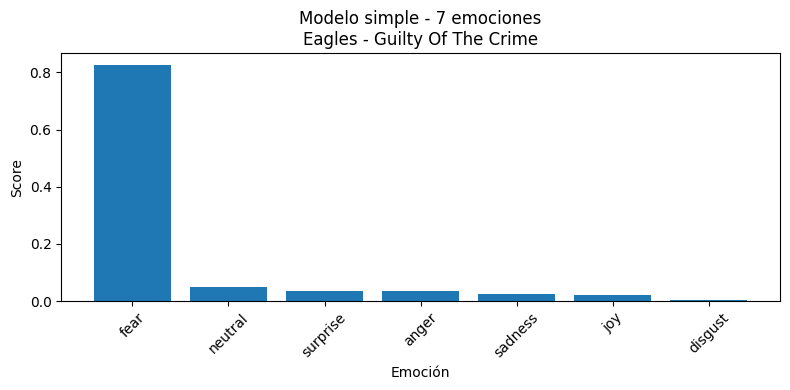

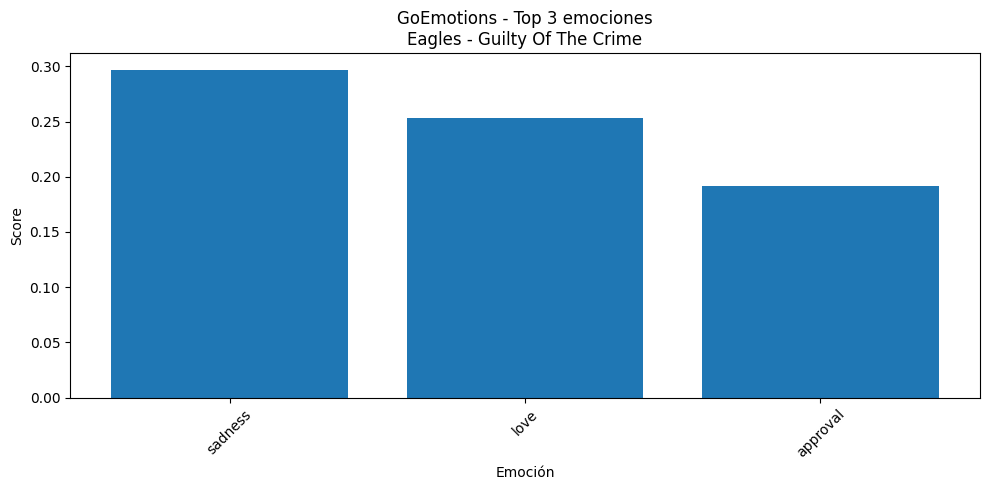

In [307]:
simple_result, complex_result = compare_song_sentiment(
    index=178,
    top_k_go=3
)

---

### 5. Agregación por género.

Después de calcular el sentimiento por canción, se agrupa por género.

Métricas recomendadas por género:

+ n_canciones

+ sentimiento_medio

+ sentimiento_mediano

+ desviación_típica

+ % Sentimiento_1

+ % Sentimiento_2

+ % Sentimiento_X

---

### 6. Visualización resultados

+ Barras: sentimiento medio por género

+ Boxplot - Violinplot por género

+ Barras apiladas % sentimientos

+ Nº canciones por género